# Fitness Watch Data Analysis: Movement Patterns from Apple Watch Data

**Dataset:** Apple Watch fitness export covering step count, distance, energy burned, and walking speed across ~149 timestamped readings over a 2-week period.

**Goal:** Move beyond raw step counts to understand *when* and *how efficiently* someone moves throughout the day.

In [1]:
import pandas as pd 
import plotly.io as pio
import plotly.graph_objects as go
pio.templates.default="plotly_white"
import plotly.express as px

In [2]:
data= pd.read_csv("Apple-Fitness-Data.csv")

In [3]:
print(data.head())

         Date       Time  Step Count  Distance  Energy Burned  \
0  2023-03-21  16:01:23           46   0.02543         14.620   
1  2023-03-21  16:18:37          645   0.40041         14.722   
2  2023-03-21  16:31:38           14   0.00996         14.603   
3  2023-03-21  16:45:37           13   0.00901         14.811   
4  2023-03-21  17:10:30           17   0.00904         15.153   

   Flights Climbed  Walking Double Support Percentage  Walking Speed  
0                3                              0.304          3.060  
1                3                              0.309          3.852  
2                4                              0.278          3.996  
3                3                              0.278          5.040  
4                3                              0.281          5.184  


In [45]:
## checking null values

print(data.isnull().sum())

numeric_columns = ['Step Count', 'Distance', 'Energy Burned', 'Flights Climbed',
                   'Walking Double Support Percentage', 'Walking Speed']
for col in numeric_columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=numeric_columns)

Date                                 0
Time                                 0
Step Count                           0
Distance                             0
Energy Burned                        0
Flights Climbed                      0
Walking Double Support Percentage    0
Walking Speed                        0
walking Efficiency                   0
Walking Efficiency                   0
Time Interval                        0
dtype: int64


#Step count over Time 

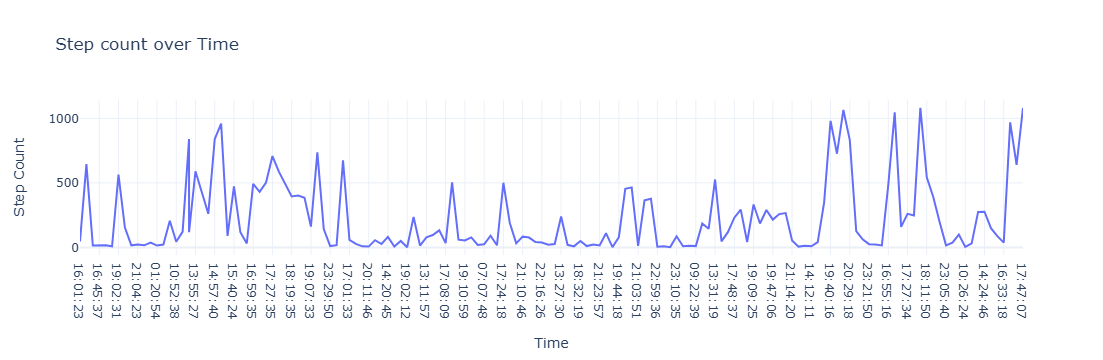

In [16]:
fig1= px.line(data, x='Time', y='Step Count', title='Step count over Time')
fig1.show()

#Distance covered over time 

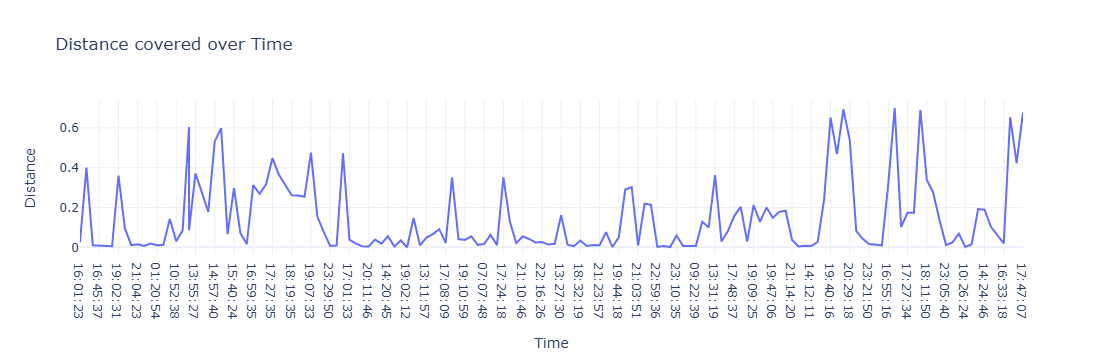

In [9]:
fig2= px.line(data, x='Time', y='Distance', title='Distance covered over Time')
fig2.show()

#Energy burnt over Time

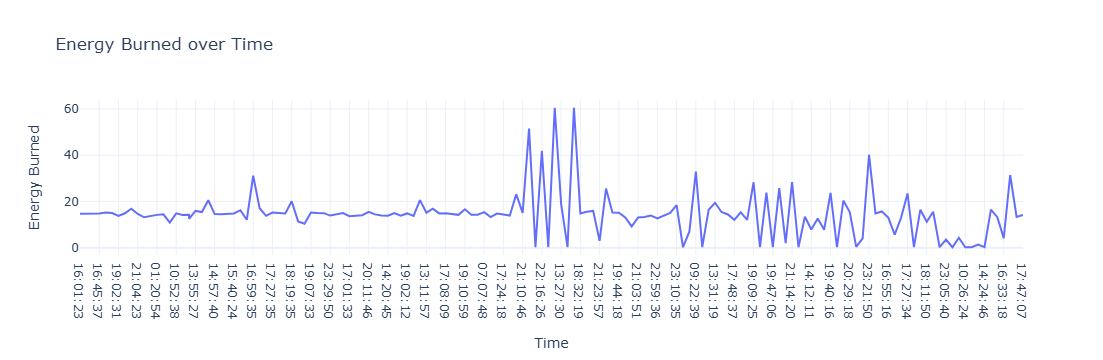

In [17]:
fig3= px.line(data, x='Time', y='Energy Burned', title='Energy Burned over Time')
fig3.show()

#Walking Speed over Time

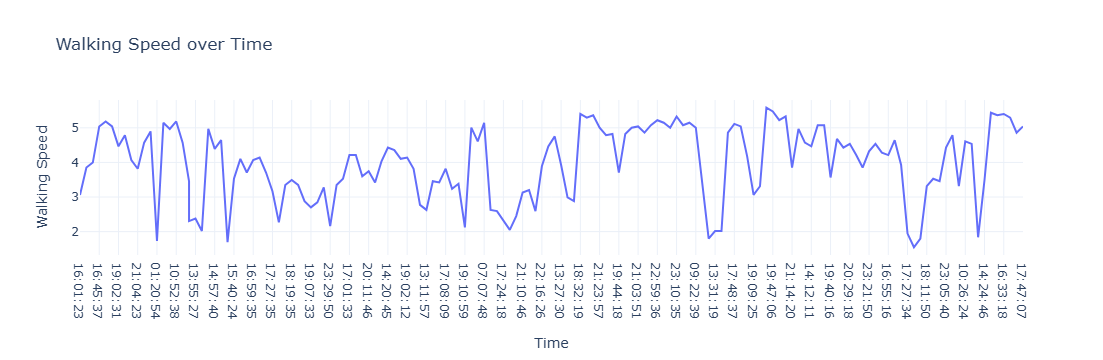

In [44]:
fig4= px.line(data, x='Time', y='Walking Speed', title='Walking Speed over Time')
fig4.show()

#Average step count per day

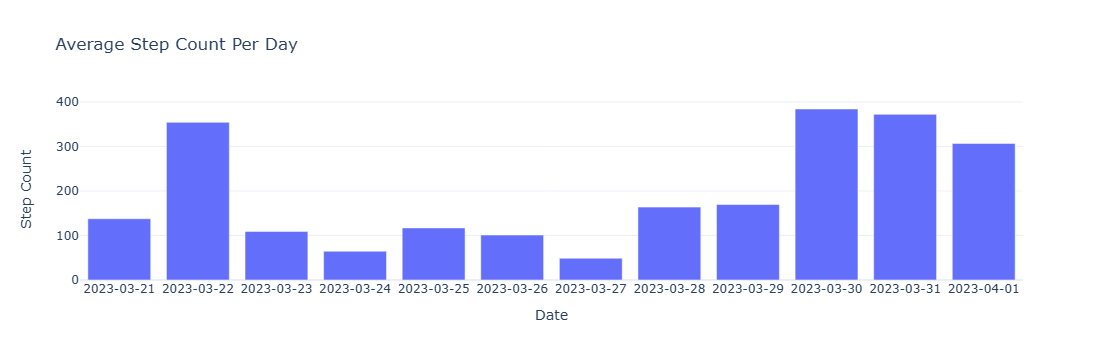

In [27]:
avg_step_count_per_day=data.groupby('Date')['Step Count'].mean().reset_index()

fig5=px.bar(avg_step_count_per_day,
            x='Date', y='Step Count',
            title= 'Average Step Count Per Day'
           )
fig5.update_xaxes(type='category')
fig5.show()

#Walking Efficiency

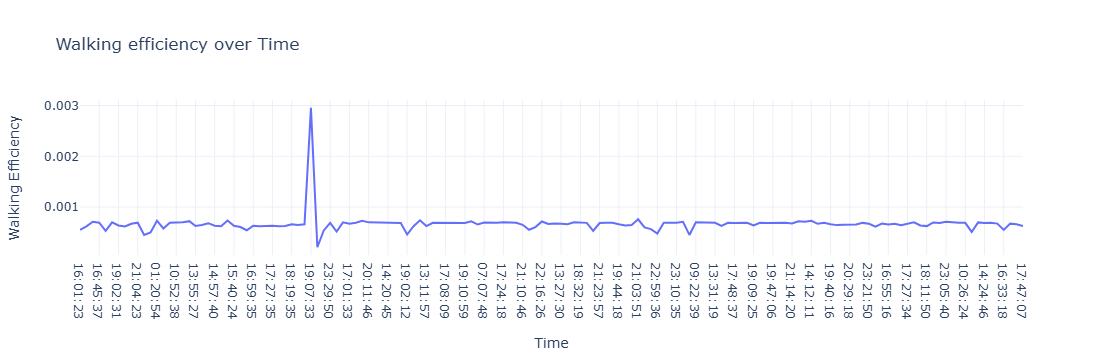

In [30]:
data["Walking Efficiency"]=data["Distance"]/data["Step Count"]

fig6=px.line(data, x='Time', y='Walking Efficiency',
               title='Walking efficiency over Time')

fig6.show()               

#Step count and walking speed variations by Time interval

C:\Users\Purva Bokil\AppData\Local\Temp\ipykernel_4088\835235817.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.

C:\Users\Purva Bokil\anaconda3\Lib\site-packages\plotly\express\_core.py:1958: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



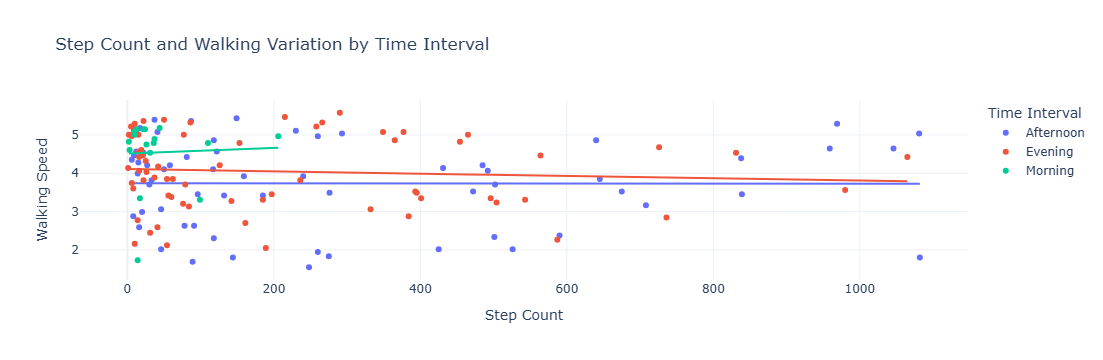

In [46]:
#creating time intervals
time_intervals= pd.cut(pd.to_datetime(data['Time']).dt.hour,
                       bins= [0,12,18,24],
                       labels=['Morning', 'Afternoon', 'Evening'],
                       right=False)

data['Time Interval']= time_intervals

fig7=px.scatter(data, 
                 x='Step Count',
                 y='Walking Speed',
                 color='Time Interval',
                title= 'Step Count and Walking Variation by Time Interval',
                trendline='ols')

fig7.show()



# Summary

This project explores Apple Fitness wearable data to understand daily movement patterns and translate raw sensor readings into something more meaningful than a simple step count.

###  Data Preparation
Cleaned the raw export by converting key metrics (step count, distance, energy burned, walking speed) to numeric types and removing incomplete rows, leaving a reliable dataset to work from.

###  Key Findings

- **Activity comes in bursts, not a steady pace** — Step counts per reading ranged from just 1 to over 1,080, averaging around 225. This suggests movement happens in short, uneven bursts throughout the day rather than continuous walking.

- **Energy burned tracks closely with movement** — Readings averaged ~14.5 kcal, spiking to over 60 kcal during the most active bursts, confirming energy expenditure scales directly with activity intensity.

- **Walking speed stayed relatively stable** — Averaging ~3.97 units even as step count swung widely, suggesting the *pace* of movement varies less than how *often* someone moves.

- **Daily consistency was the real gap** — Average daily steps over the two-week window ranged from ~49 to ~384, nearly an **8x difference** between the least and most active day — highlighting irregular activity habits rather than a steady routine.

- **A custom "Walking Efficiency" metric** (distance covered per step) was built to measure movement *quality* rather than just quantity. This surfaced days with short, choppy steps versus days with longer, more efficient strides — something step count alone would have missed.

- **Time-of-day patterns emerged** — Mornings had fewer logged readings but the most consistent, fastest walking speeds. Afternoons showed the widest variation in pace, hinting at more start-stop movement. Evenings had the most readings overall, with moderate speed and consistency.

###  Why It Matters
By digging past step count into metrics like walking efficiency and time-of-day variation, fitness platforms can move from generic step-goal nudges to more targeted, personalized coaching — encouraging longer strides, steadier pacing, or more consistent daily activity based on what the data actually shows.

### Limitations
This analysis is based on a single user's data over a 2-week period, so patterns may not generalize across users or longer timeframes.